In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import geopandas as gpd

url = "https://drive.google.com/uc?id=1etEWfFoUnXSyNHtM26Db83xchb_mLBzA"

df = pd.read_csv(url)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23967 entries, 0 to 23966
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          23967 non-null  object
 1   type          23967 non-null  object
 2   registration  22419 non-null  object
 3   operator      23963 non-null  object
 4   fatalities    20029 non-null  object
 5   location      23019 non-null  object
 6   country       23967 non-null  object
 7   cat           23967 non-null  object
 8   year          23967 non-null  object
dtypes: object(9)
memory usage: 1.6+ MB


In [ ]:
#ho provato se ci sono anni con ???? nella colonna "date" per provare a integrarli con la colonna "year", ma non risultano valori
df['date'] = df['date'].str.strip()

mask_date_sporche = df['date'].str.contains(r'\?{4}', na=False)
df_date_sporche = df[mask_date_sporche]
print(df_date_sporche)

# conta quante righe hanno ???? nella colonna date
numero_sporche = df['date'].str.contains(r'\?{4}', na=False).sum()
print(numero_sporche)

Empty DataFrame
Columns: [date, type, registration, operator, fatalities, location, country, cat, year]
Index: []
0


In [ ]:
#cambia i ??? a gennaio e poi ?? a 01 per date fittizie, messo prima i 3??? per non creare confusione
df["date_clean"] = (df["date"].str.replace("???", "JAN", regex=False).str.replace("??", "01", regex=False))

#prova carattere cambiato su data_clean
prova = df.iloc[84]
print(prova)

date                   ??-???-1923
type                 Aeromarine 75
registration                   NaN
operator        Aeromarine Airways
fatalities                       0
location            Havana harbour
country                       Cuba
cat                             O1
year                          1923
date_clean             01-JAN-1923
Name: 84, dtype: object


In [ ]:
df["date"] = pd.to_datetime(df["date"], format="%d-%b-%Y", errors="coerce") #colonna date cambiata in datetime
df["date_clean"] = pd.to_datetime(df["date_clean"], format="%d-%b-%Y", errors="coerce") #colonna date_clean cambiata in datetime
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23967 entries, 0 to 23966
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          23408 non-null  datetime64[ns]
 1   type          23967 non-null  object        
 2   registration  22419 non-null  object        
 3   operator      23963 non-null  object        
 4   fatalities    20029 non-null  object        
 5   location      23019 non-null  object        
 6   country       23967 non-null  object        
 7   cat           23967 non-null  object        
 8   year          23967 non-null  object        
 9   date_clean    23905 non-null  datetime64[ns]
dtypes: datetime64[ns](2), object(8)
memory usage: 1.8+ MB


In [ ]:
#Colonna type
valori_unici_type = df['type'].unique() # Mostra tutti i valori unici della colonna
print(valori_unici_type)

valori_sospetti_type = [v for v in valori_unici_type if isinstance(v, str) and "unknown" in v.lower()]
print("Valori sospetti:", valori_sospetti_type)

#ho sommato i valori unknown e unknown jetliner
conteggio1 = (df['type'].str.lower() == 'unknown').sum()
print("Conteggio (unknown):", conteggio1)
conteggio2 = (df['type'].str.lower() == 'unknown jetliner').sum()
print("Conteggio (unknown jetliner):", conteggio2)

['Antonov An-12B' 'Antonov An-12BK' 'Antonov An-12BP' ...
 'Antonov An-72-100D' 'Boeing 737-33A (SF)' 'Boeing 777-233LR']
Valori sospetti: ['unknown', 'unknown jetliner']
Conteggio (unknown): 34
Conteggio (unknown jetliner): 1


In [ ]:
df['type'] = df['type'].replace(['unknown'], 'unknown jetliner') #unknown modificato in unknown jetliner
conteggio1 = (df['type'].str.lower() == 'unknown').sum()
print("Conteggio (unknown) dopo modifica:", conteggio1)
conteggio2 = (df['type'].str.lower() == 'unknown jetliner').sum()
print("Conteggio (unknown jetliner) dopo modifica:", conteggio2)
df['type'] = df['type'].str.strip().str.title() #elimina spazi all’inizio e alla fine e mette in maiuscolo la prima lettera di ogni parola

Conteggio (unknown) dopo modifica: 0
Conteggio (unknown jetliner) dopo modifica: 35


In [ ]:
valori_unici_type = df['type'].unique() #mostra valori unici
valori_sospetti_type = [v for v in valori_unici_type if isinstance(v, str) and "?" in v.lower()] #cerca volori sospetti (ho fatto ricerca anche con altri valori tipo !)
print(valori_sospetti_type)

['Ilyushin Il-14 ?', 'Ilyushin Il-12 ?', 'Antonov An-12 ?', 'Antonov An-24 ?', 'Tupolev Tu-134 ?', 'Ilyushin Il-62 ?', 'Fokker 100 ?', 'Airbus A320 ?', 'Airbus A300B4-605R ?', 'Fokker 50?', 'Airbus A300B4-620 ?', 'Boeing 727-200 ?', 'Airbus A300?', 'Atr 42-500 ?', 'Boeing 737-500 ?', 'Dornier 328 ?', 'Gulfstream ?']


In [ ]:
df['type'] = df['type'].astype(str).str.replace(r'[?]', '', regex=True).str.strip()

In [ ]:
valori_unici_type = df['type'].unique() #hp rifatto la prova per vedere se c'erano ancora
valori_sospetti_type = [v for v in valori_unici_type if isinstance(v, str) and "?" in v.lower()]
print(valori_sospetti_type)

[]


In [ ]:
valori_unici_reg = df['registration'].unique() # Mostra tutti i valori unici della colonna
conteggio = df["registration"].value_counts()
print(conteggio.head(30))

registration
LZ-...     13
-          11
unreg.      6
39          5
N3125N      4
70          4
VT-EDS      4
LV-JNE      4
HK-1337     4
48          4
VT-DOL      3
210         3
HK-757      3
01          3
53          3
N401LC      3
ET-AJB      3
T-21        3
B-150       3
N37AP       3
101         3
7251        3
T-83        3
HK-400      3
N851JA      3
HK-1058     3
102         3
VT-DMB      3
HK-1408     3
B-2138      3
Name: count, dtype: int64


In [ ]:
df["registration"] = df["registration"].replace("-", np.nan) #sostituito il valore "-" con nan
df["registration"] = df["registration"].replace("unreg.", np.nan) #sostituito il valore "unreg." con nan, l'ho valutato come unregistration = non registrato
conteggio = df["registration"].value_counts()
print(conteggio.head(30))

registration
LZ-...     13
39          5
N3125N      4
70          4
VT-EDS      4
HK-1337     4
48          4
LV-JNE      4
53          3
HK-757      3
N401LC      3
VT-DOL      3
210         3
T-83        3
01          3
ET-AJB      3
T-21        3
B-150       3
N37AP       3
7251        3
101         3
HK-400      3
N851JA      3
HK-1058     3
102         3
VT-DMB      3
HK-1408     3
B-2138      3
02          3
PP-PDX      3
Name: count, dtype: int64


In [ ]:
valori_unici = df['operator'].value_counts() # Mostra tutti i valori unici della colonna
print(valori_unici.head(30))

operator
USAAF                     2604
USAF                      1120
RAF                        920
US Navy                    745
German AF                  517
private                    299
Aeroflot                   198
Unknown                    185
Soviet AF                  142
Air France                 138
RAAF                       130
American Airlines          116
French AF                  113
Indian Airlines            109
Spanish AF                 108
Eastern Air Lines          105
TWA                        105
RCAF                       104
Brazilian AF               103
United Airlines            100
Indian AF                   99
Aeroflot, Yakutsk           98
BOAC                        92
Pan Am                      92
Delta Air Lines             81
Aeroflot, Ukraine           80
Philippine Air Lines        74
Avianca                     73
CNAC                        72
Aeroflot, East Siberia      70
Name: count, dtype: int64


In [ ]:
#colonna operator
df["operator"] = df["operator"].str.lower().replace(["unknown"], np.nan) #Sostituisco i valori "unknown" con NaN nella colonna "operator"
df["operator"] = df["operator"].replace(['usaaf','usaf'], 'usa af') #i valori "usaaf" e "usaf" li vo vautati come stessa compagnia  e cambiati in "usa af"
df["operator"] = df["operator"].replace(['rcaf','raaf'], 'raf') #i valori "rcaf" e "raaf" li ho cambiati in "raf" valutandoli come stessa compagnia
df["operator"] = df["operator"].str.title() #Trasforma la prima lettera di ogni parola in maiuscolo

In [ ]:
valori_unici = df['operator'].value_counts() # Mostra tutti i valori unici della colonna
print(valori_unici.head(30))

operator
Usa Af                    3724
Raf                       1154
Us Navy                    745
German Af                  517
Private                    352
Aeroflot                   198
Soviet Af                  142
Air France                 138
American Airlines          116
French Af                  113
Indian Airlines            109
Spanish Af                 108
Eastern Air Lines          105
Twa                        105
Brazilian Af               103
United Airlines            100
Indian Af                   99
Aeroflot, Yakutsk           98
Pan Am                      92
Boac                        92
Delta Air Lines             81
Aeroflot, Ukraine           80
Philippine Air Lines        74
Avianca                     73
Cnac                        72
Aeroflot, East Siberia      70
Ethiopian Airlines          68
Aeroflot, Moscow            66
Lot                         65
Klm                         63
Name: count, dtype: int64


In [ ]:
valori_unici_oper = df['operator'].unique() # Mostra tutti i valori unici della colonna

valori_sospetti_oper = [v for v in valori_unici_oper if isinstance(v, str) and "?" in v.lower()] #ricerca valori sospetti
print(valori_sospetti_oper)

['Cornerstone Construction ?', 'Eagle Aviation ?']


In [ ]:
df['operator'] = df['operator'].str.replace('[?]', '', regex=True).str.strip() #cambiato il ? presente nella stringa, strip per rimuovere spazi finali e iniziali
valori_unici_oper = df['operator'].unique() # Mostra tutti i valori unici della colonna

valori_sospetti_oper = [v for v in valori_unici_oper if isinstance(v, str) and "?" in v.lower()] #ricontrollo se risultano ancora
print(valori_sospetti_oper)

[]


In [ ]:
valori_unici_fat = df["fatalities"].unique() #Mostra valori unici
print(valori_unici_fat)

[nan '0' '14' '1' '4' '2' '5' '6' '3' '7' '5+ 1' '8' '16' '12' '9' '15'
 '14+ 1' '10' '11' '35+ 9' '13' '2+ 2' '17' '19' '20' '0+ 1' '18' '13+ 1'
 '25' '29' '23' '5+ 7' '24' '36' '26' '22' '27' '12+ 1' '21' '7+ 6' '35'
 '32' '31' '2+ 1' '34' '28' '20+ 5' '0+ 2' '30' '41' '59' '13+ 7' '45'
 '44' '37' '3+ 5' '4+ 6' '30+ 1' '19+ 1' '39' '11+ 1' '43' '53' '0+ 3'
 '50' '14+ 3' '3+ 1' '52' '8+ 1' '5+ 3' '40' '0+ 6' '8+ 2' '33' '48' '55'
 '1+ 1' '38' '0+ 7' '32+ 1' '13+ 2' '80' '1+ 2' '46' '58' '51' '10+ 3'
 '56' '23+ 7' '29+ 4' '2+ 3' '5+ 2' '87' '129' '42' '5+ 10' '35+ 1' '47'
 '66' '1+ 4' '5+ 4' '74' '70' '62' '17+ 1' '4+ 3' '18+ 2' '20+ 2' '67'
 '79' '5+ 6' '6+ 1' '61' '41+ 1' '21+ 2' '99' '64' '3+ 4' '65' '1+ 9' '68'
 '54' '3+ 8' '32+ 10' '6+ 2' '63' '7+ 1' '84+ 6' '20+ 32' '6+ 3' '72+ 1'
 '78' '72' '27+ 3' '83' '77' '3+ 2' '95' '111' '107' '130' '113' '84' '94'
 '81' '86' '97' '6+ 7' '14+ 87' '7+ 2' '101' '15+ 1' '118' '85' '49'
 '79+ 1' '57' '7+ 22' '121' '3+ 11' '11+ 3' '117' '133' '1

In [ ]:
df["fatalities"] = df["fatalities"].astype(str).str.replace(" ", "") #ho eliminato spazio tra numeri e "+"" altrimenti eval non funziona
df["fatalities_num"] = df["fatalities"].apply(lambda x: eval(x) if x not in ('', 'nan') else np.nan) # Applica eval se il valore non è '' o 'nan', altrimenti mette NaN
df["fatalities_num"] = pd.to_numeric(df["fatalities_num"], errors="coerce").astype('Int64') #il risultato dell' eval fatta in precedenza ora viene cambiata in numerica

In [ ]:
valori_unici_fat_n = df["fatalities_num"].unique() #Mostra valori unici
print(valori_unici_fat_n)

<IntegerArray>
[<NA>,    0,   14,    1,    4,    2,    5,    6,    3,    7,
 ...
  149,  199,  152,  168,  158,  127,  239,  298,  139,  224]
Length: 204, dtype: Int64


In [ ]:
valori_unici_l = df["location"].unique() #Mostra valori unici
print(valori_unici_l)

[nan 'Tiksi Airport (IKS)' 'Massawa Airport ...' ... 'Fentheik Airstrip'
 'Kampala-Kajjansi...' 'Hohn Air Base']


In [ ]:
#ho fatto le varie ricerche con valori sospetti ed altro, e controllo dopo, ho notato che c'erano perentesi "(" e "[" isolate
df["location"] = df["location"].str.replace(r"[^a-zA-Z\s\-\(\)\[\]]", "", regex=True) #Rimuove tutto tranne lettere, spazi, trattini e parentesi tonde/quadre
df["location"] = df["location"].str.replace(r'^\s*[\(\)\[\]]\s*$', '', regex=True) #Rimuove parentesi isolate (anche con spazi attorno)
df["location"] = df["location"].str.strip() #Rimuove spazi in eccesso
df["location"] = df["location"].str.lower().replace("unknown", np.nan) #i valori unknown diventano nan
df["location"] = df["location"].str.title()

In [ ]:
valori_unici_oper = df['country'].unique() # Mostra tutti i valori unici della colonna
conteggio = df["country"].value_counts()
print(conteggio)

country
USA                4377
Russia             1422
Unknown country     838
U.K.                837
Canada              826
                   ... 
Cook Isl.             1
Kosovo                1
Burundi               1
Eswatini              1
Macau                 1
Name: count, Length: 232, dtype: int64


In [ ]:
df["country"] = df["country"].str.lower().replace("unknown country", np.nan) #i valori "unknown coutry" cambiati in nan
df["country"] = df["country"].str.title()

In [ ]:
conteggio = df["country"].value_counts()
print(conteggio)

country
Usa          4377
Russia       1422
U.K.          837
Canada        826
India         700
             ... 
Cook Isl.       1
Kosovo          1
Burundi         1
Eswatini        1
Macau           1
Name: count, Length: 231, dtype: int64


In [ ]:
valori_unici_country = df['country'].unique() #Mostra valori unici
valori_sospetti_country = [v for v in valori_unici_country if isinstance(v, str) and "?" in v.lower()] #vari controlli fatti
print(valori_sospetti_country)

['?']


In [ ]:
df['country'] = df['country'].replace('?', np.nan)

In [ ]:
valori_unici_country = df['country'].unique()
valori_sospetti_country = [v for v in valori_unici_country if isinstance(v, str) and "?" in v.lower()] #rifacio il controllo per vedere se è stato cambiato
print(valori_sospetti_country)

[]


In [ ]:
conteggio = df["cat"].value_counts()
print(conteggio)

cat
A1    17424
A2     2494
C1     1185
H2     1052
O1     1035
U1      571
C2       84
O2       65
H1       42
I2       12
I1        3
Name: count, dtype: int64


In [ ]:
df["year"] = pd.to_numeric(df["year"], errors='coerce').astype('Int64') #colonna year cambiata in numerico e intero

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23967 entries, 0 to 23966
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            23408 non-null  datetime64[ns]
 1   type            23967 non-null  object        
 2   registration    22402 non-null  object        
 3   operator        23778 non-null  object        
 4   fatalities      23967 non-null  object        
 5   location        22701 non-null  object        
 6   country         23110 non-null  object        
 7   cat             23967 non-null  object        
 8   year            23906 non-null  Int64         
 9   date_clean      23905 non-null  datetime64[ns]
 10  fatalities_num  20029 non-null  Int64         
dtypes: Int64(2), datetime64[ns](2), object(7)
memory usage: 2.1+ MB


In [ ]:
#Nazioni con piu incidenti
#Conta gli incidenti per nazione, prende le prime 10, resetta l'indice per partire da 0 altrimenti metterebbe la posizioine in cui si trova
top10_country = df["country"].value_counts().head(10).reset_index()
#rinomina le colonne per leggibilità
top10_country.columns = ['Nazione', 'Incidenti']
print(top10_country)

nazione_piu_inc = top10_country.iloc[0]['Nazione'] #Prendo prima valore di nazione per fare print spiegato
conteggio_massimo = top10_country.iloc[0]['Incidenti'] #Prendo prima valore di incidenti per fare print spiegato
print(f"{nazione_piu_inc} è la nazione con più incidenti: {conteggio_massimo}")

    Nazione  Incidenti
0       Usa       4377
1    Russia       1422
2      U.K.        837
3    Canada        826
4     India        700
5    Brazil        609
6    France        550
7   Germany        516
8     China        514
9  Colombia        457
Usa è la nazione con più incidenti: 4377


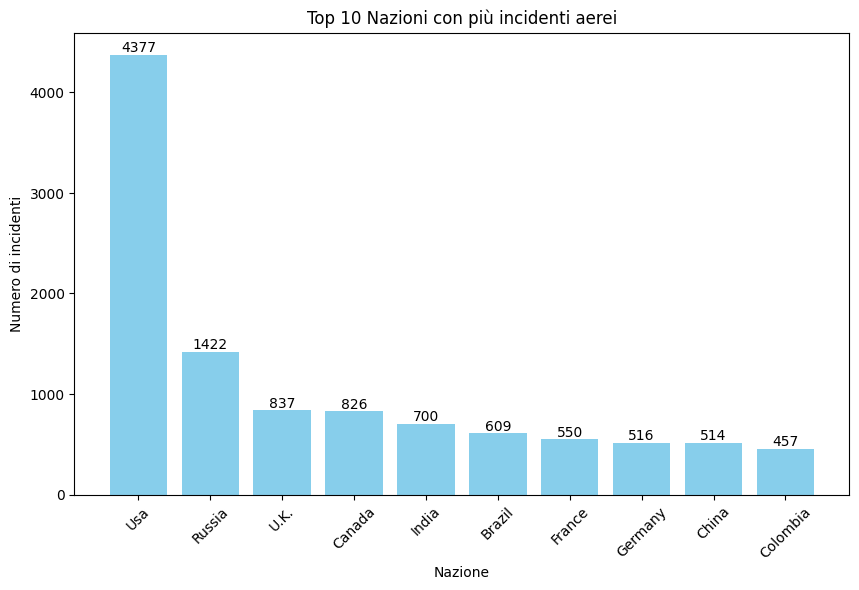

In [ ]:
plt.figure(figsize=(10,6))
bars = plt.bar(top10_country['Nazione'], top10_country['Incidenti'], color="skyblue")

plt.title("Top 10 Nazioni con più incidenti aerei")
plt.xlabel("Nazione")
plt.ylabel("Numero di incidenti")
plt.xticks(rotation=45)

# Numeri sopra ogni barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, str(height),
             ha='center', va='bottom')

plt.show()


In [ ]:
# Calcola il giorno della settimana per ogni incidente
df['Giorno_settimana'] = df['date'].dt.day_name()

# Conta quanti incidenti ci sono in ciascun giorno della settimana
incidenti_per_giorno = df['Giorno_settimana'].value_counts().reset_index()
incidenti_per_giorno.columns = ['Giorno', 'Conteggio'] #rinomina colonne per leggibilità
print(incidenti_per_giorno)

giorno_piu_incidenti = incidenti_per_giorno.iloc[0]['Giorno'] # Giorno con più incidenti
conteggio_massimo = incidenti_per_giorno.iloc[0]['Conteggio']
print(f"{giorno_piu_incidenti} è il giorno della settimana con più incidenti con {conteggio_massimo} incidenti")



      Giorno  Conteggio
0     Friday       3701
1   Thursday       3516
2  Wednesday       3491
3    Tuesday       3444
4     Monday       3317
5   Saturday       3186
6     Sunday       2753
Friday è il giorno della settimana con più incidenti con 3701 incidenti


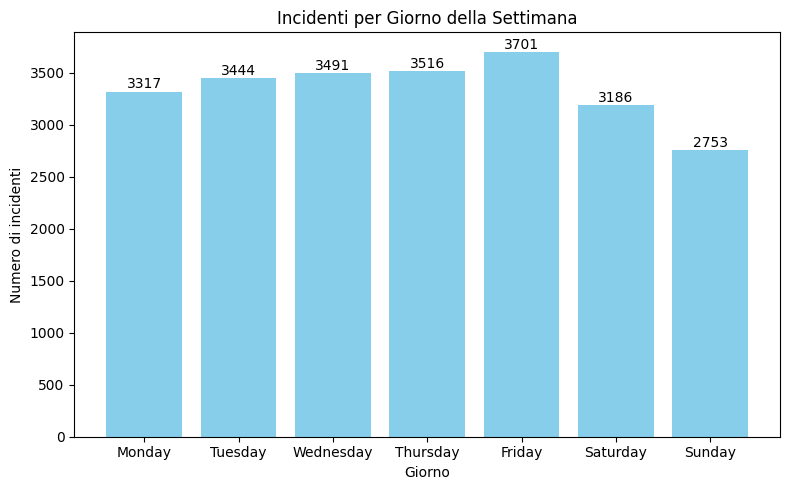

In [ ]:
# Calcola il giorno della settimana per ogni incidente
df['Giorno_settimana'] = df['date'].dt.day_name()

# Conta gli incidenti per giorno
incidenti_per_giorno = df['Giorno_settimana'].value_counts()

# Ordine dei giorni in inglese
ordine_giorni = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Prendi i conteggi nell'ordine desiderato, se un giorno non c'è lo mette a 0
conteggi_ordinati = [incidenti_per_giorno.get(giorno, 0) for giorno in ordine_giorni]

# Grafico a barre
plt.figure(figsize=(8,5))
bars = plt.bar(ordine_giorni, conteggi_ordinati, color='skyblue')

# Numeri sopra le barre
for bar, val in zip(bars, conteggi_ordinati):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.5, val,
             ha='center', va='bottom', fontsize=10)

plt.title("Incidenti per Giorno della Settimana")
plt.xlabel("Giorno")
plt.ylabel("Numero di incidenti")
plt.tight_layout()
plt.show()


In [ ]:

incidenti_operatori = (df['operator'].value_counts().head(10).reset_index()) #Conta il numero di incidenti per operatore, prende i primi 10 e resetta l'indice
incidenti_operatori.columns = ['Operatore', 'Incidenti'] #rinomina le colonne per leggibilità
print(incidenti_operatori)

operatore_piu_morti = incidenti_operatori.iloc[0]['Operatore'] # Giorno con più incidenti
conteggio_massimo = incidenti_operatori.iloc[0]['Incidenti']
print(f"Operatore con più incidenti: {operatore_piu_morti} con {conteggio_massimo} incidenti")


           Operatore  Incidenti
0             Usa Af       3724
1                Raf       1154
2            Us Navy        745
3          German Af        517
4            Private        352
5           Aeroflot        198
6          Soviet Af        142
7         Air France        138
8  American Airlines        116
9          French Af        113
Operatore con più incidenti: Usa Af con 3724 incidenti


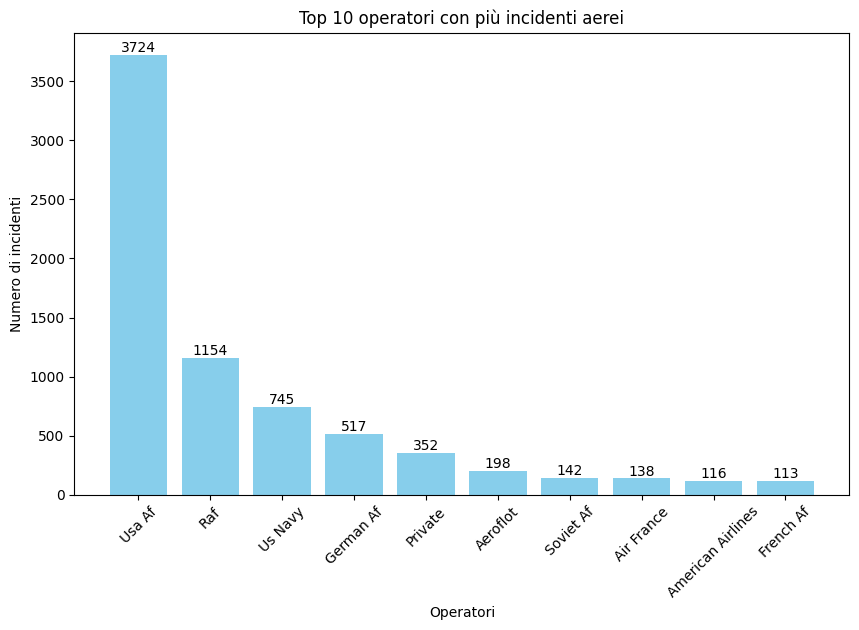

In [ ]:
plt.figure(figsize=(10,6))
bars = plt.bar(incidenti_operatori['Operatore'], incidenti_operatori['Incidenti'], color="skyblue")

plt.title("Top 10 operatori con più incidenti aerei")
plt.xlabel("Operatori")
plt.ylabel("Numero di incidenti")
plt.xticks(rotation=45)

# Aggiungiamo i numeri sopra ogni barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, str(height),
             ha='center', va='bottom')

plt.show()

In [ ]:
#incidenti per veicolo
#Somma delle vittime per veicolo, ordina dal più alto, prende i top 10 e resetta l'indice
morti_totali_veicolo = (df.groupby('type')['fatalities_num'].sum().sort_values(ascending=False).head(10).reset_index())
morti_totali_veicolo.columns = ["Veicolo", "Morti"] #rinomina le colonne per leggibilità
print(morti_totali_veicolo)

veicolo_piu_morti = morti_totali_veicolo.iloc[0]['Veicolo']
conteggio_massimo = morti_totali_veicolo.iloc[0]['Morti']
print(f"Veicolo con più morti: {veicolo_piu_morti} con {conteggio_massimo} morti")


                    Veicolo  Morti
0      Douglas C-47A (Dc-3)   5780
1       Douglas C-47 (Dc-3)   2676
2      Douglas C-47B (Dc-3)   2017
3          Boeing 767-223Er   1692
4           Tupolev Tu-154M   1600
5                   Dc-9-32   1441
6           Ilyushin Il-18V   1356
7  Lockheed C-130H Hercules   1271
8             Antonov An-26   1246
9          Junkers Ju-52/3M   1114
Veicolo con più morti: Douglas C-47A (Dc-3) con 5780 morti


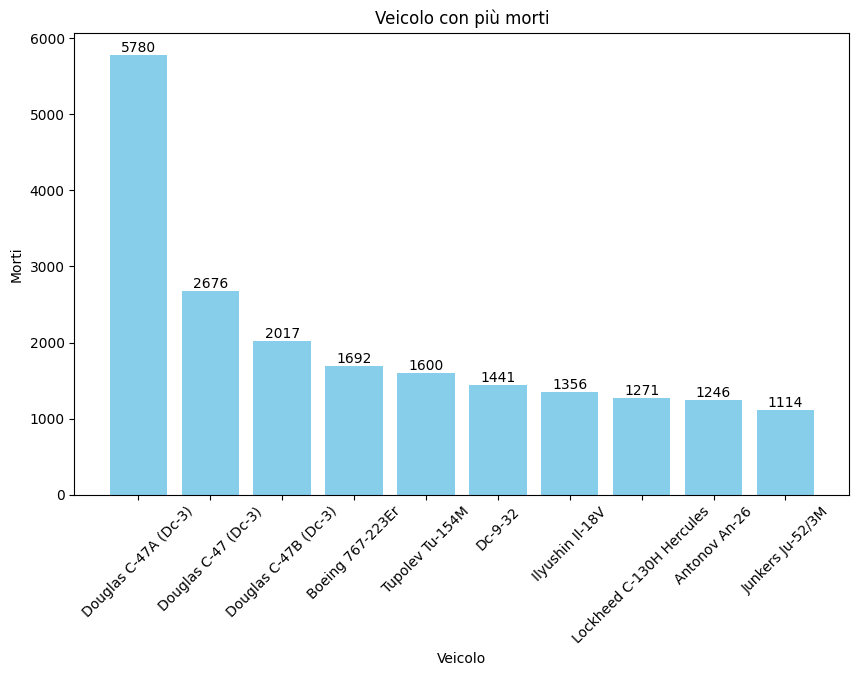

In [ ]:
plt.figure(figsize=(10,6))
bars = plt.bar(morti_totali_veicolo['Veicolo'], morti_totali_veicolo['Morti'], color="skyblue")

plt.title("Veicolo con più morti")
plt.xlabel("Veicolo")
plt.ylabel("Morti")
plt.xticks(rotation=45)

# Aggiungiamo i numeri sopra ogni barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, str(height),
             ha='center', va='bottom')

plt.show()

In [ ]:
morti_per_anno = df.groupby(df['date_clean'].dt.year)['fatalities_num'].sum()
media_morti_pre = morti_per_anno[morti_per_anno.index < 2001].mean().round(2)
media_morti_post = morti_per_anno[morti_per_anno.index >= 2001].mean().round(2)

print("Media morti per anno prima del 2001:", media_morti_pre)
print("Media morti per anno dopo il 2001:", media_morti_post)


Media morti per anno prima del 2001: 1366.24
Media morti per anno dopo il 2001: 900.0


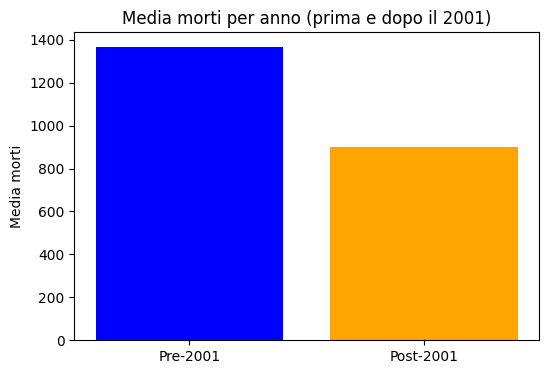

In [ ]:
# Grafico confronto medie
plt.figure(figsize=(6,4))
plt.bar(['Pre-2001','Post-2001'], [media_morti_pre, media_morti_post], color=['blue','orange'])
plt.title("Media morti per anno (prima e dopo il 2001)")
plt.ylabel("Media morti")
plt.show()

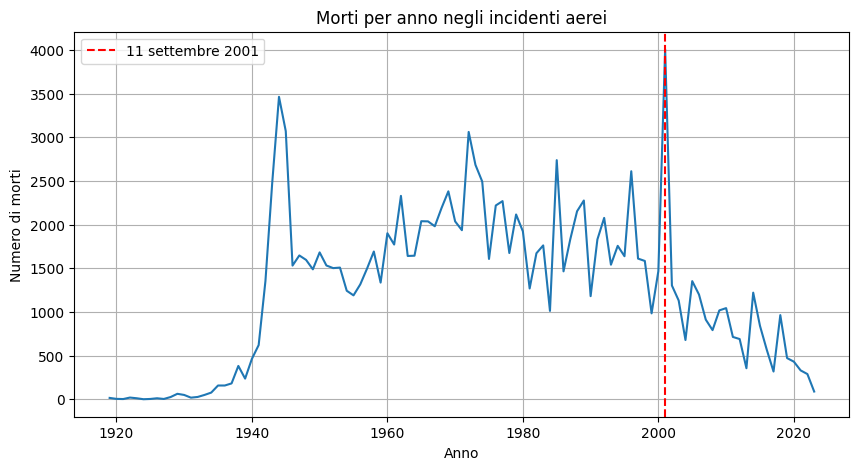

In [ ]:
# Grafico dell'andamento
plt.figure(figsize=(10,5))
plt.plot(morti_per_anno.index, morti_per_anno.values)
plt.axvline(2001, color='red', linestyle='--', label='11 settembre 2001')
plt.title("Morti per anno negli incidenti aerei")
plt.xlabel("Anno")
plt.ylabel("Numero di morti")
plt.legend()
plt.grid()
plt.show()

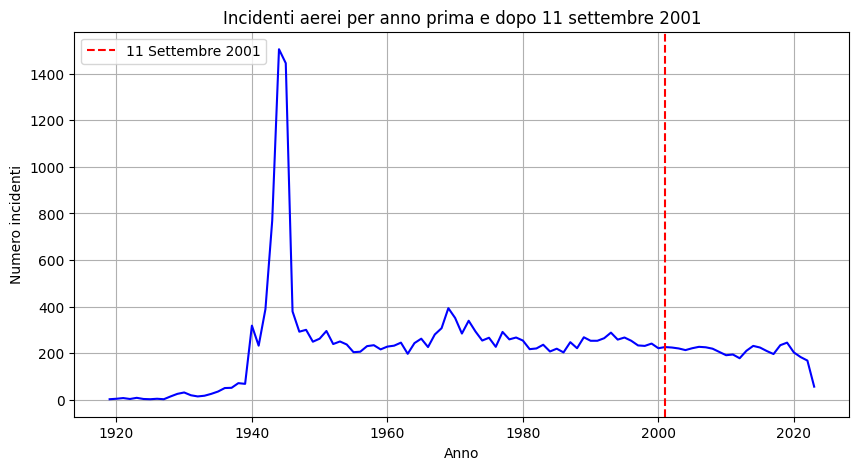

In [ ]:
# Numero di incidenti per anno
incidenti_per_anno = df.groupby('year').size().reset_index(name='Incidenti')

plt.figure(figsize=(10,5))
plt.plot(incidenti_per_anno['year'], incidenti_per_anno['Incidenti'], color='blue')

# Linea verticale per indicare l'11 settembre 2001
plt.axvline(x=2001, color='red', linestyle='--', label="11 Settembre 2001")

plt.title("Incidenti aerei per anno prima e dopo 11 settembre 2001")
plt.xlabel("Anno")
plt.ylabel("Numero incidenti")
plt.legend()
plt.grid()
plt.show()


In [ ]:
#Incidenti con più morti per anno
#Somma delle vittime per anno, ordina dal più alto, prende i 5 anni con più morti e resetta l'indice
morti_per_anno = (df.groupby(df['year'])['fatalities_num'].sum().sort_values(ascending=False).head(5).reset_index())
morti_per_anno.columns = ["Anno", "Morti"] #rinomina le colonne per leggibilità
print(morti_per_anno)

anno_piu_morti = morti_per_anno.iloc[0]['Anno']
conteggio_massimo = morti_per_anno.iloc[0]['Morti']
print(f"Il {anno_piu_morti} è l'anno con più morti con {conteggio_massimo} morti")


   Anno  Morti
0  2001   4007
1  1944   3462
2  1945   3069
3  1972   3060
4  1985   2737
Il 2001 è l'anno con più morti con 4007 morti


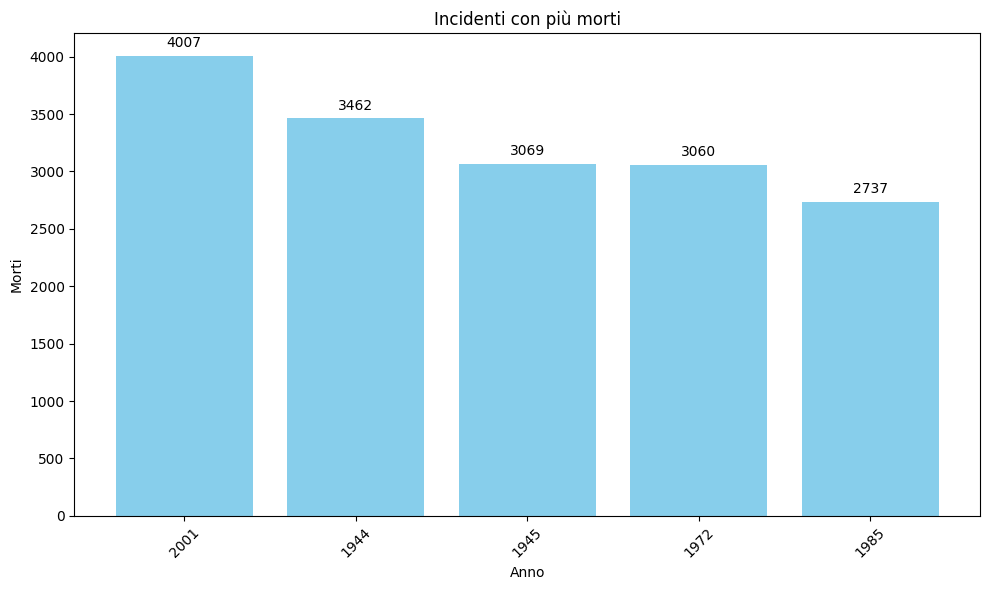

In [ ]:
plt.figure(figsize=(10,6))
morti_per_anno['Anno'] = morti_per_anno['Anno'].astype(str)

plt.bar(morti_per_anno['Anno'], morti_per_anno['Morti'], color="skyblue")
plt.title("Incidenti con più morti")
plt.xlabel("Anno")
plt.ylabel("Morti")
plt.xticks(rotation=45)

# Aggiungiamo i numeri sopra ogni barra
for i, v in enumerate(morti_per_anno['Morti']):
    plt.text(morti_per_anno['Anno'][i], v + 50, str(v), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
#incidenti per categoria
#Conta gli incidenti per categoria, ordina dal più frequente e resetta l'indice per avere un dataframe
incidenti_per_cat = df['cat'].value_counts().sort_values(ascending=False).reset_index()
incidenti_per_cat.columns = ["Categoria", "Incidenti"] #rinomina le colonne per leggibilità
print("Incidenti per categoria:\n", incidenti_per_cat)
del incidenti_per_cat #cancella dataframe temporaneo

Incidenti per categoria:
    Categoria  Incidenti
0         A1      17424
1         A2       2494
2         C1       1185
3         H2       1052
4         O1       1035
5         U1        571
6         C2         84
7         O2         65
8         H1         42
9         I2         12
10        I1          3


In [ ]:
url = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries.geo.json" #stati presenti nel dataset di Geopandas
world = gpd.read_file(url)

print(world['name'].unique())


['Afghanistan' 'Angola' 'Albania' 'United Arab Emirates' 'Argentina'
 'Armenia' 'Antarctica' 'French Southern and Antarctic Lands' 'Australia'
 'Austria' 'Azerbaijan' 'Burundi' 'Belgium' 'Benin' 'Burkina Faso'
 'Bangladesh' 'Bulgaria' 'The Bahamas' 'Bosnia and Herzegovina' 'Belarus'
 'Belize' 'Bermuda' 'Bolivia' 'Brazil' 'Brunei' 'Bhutan' 'Botswana'
 'Central African Republic' 'Canada' 'Switzerland' 'Chile' 'China'
 'Ivory Coast' 'Cameroon' 'Democratic Republic of the Congo'
 'Republic of the Congo' 'Colombia' 'Costa Rica' 'Cuba' 'Northern Cyprus'
 'Cyprus' 'Czech Republic' 'Germany' 'Djibouti' 'Denmark'
 'Dominican Republic' 'Algeria' 'Ecuador' 'Egypt' 'Eritrea' 'Spain'
 'Estonia' 'Ethiopia' 'Finland' 'Fiji' 'Falkland Islands' 'France' 'Gabon'
 'United Kingdom' 'Georgia' 'Ghana' 'Guinea' 'Gambia' 'Guinea Bissau'
 'Equatorial Guinea' 'Greece' 'Greenland' 'Guatemala' 'French Guiana'
 'Guyana' 'Honduras' 'Croatia' 'Haiti' 'Hungary' 'Indonesia' 'India'
 'Ireland' 'Iran' 'Iraq' 'Iceland' '

In [ ]:
csv_countries = set(df['country'].str.strip().unique())

# GeoDataFrame
url = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries.geo.json"
world = gpd.read_file(url)
world_countries = set(world['name'].unique())

non_corrispondenti = csv_countries - world_countries
print("Paesi nel CSV di GeoPandas non corrispondenti:", non_corrispondenti)


Paesi nel CSV di GeoPandas non corrispondenti: {'U.K.', 'Comoros', 'Atlantic Ocean', 'Maldives', 'C.A.R.', 'Cook Isl.', 'Curaã§Ao', 'Bahrain', "Cote D'Ivoire", 'Falkland Isl.', 'Hong Kong', 'Macau', 'Marshall Isl.', 'Bosnia', 'North Macedonia', 'U.S. Virgin Isl.', 'Solomon Isl.', 'U.A.E.', 'Turks & Caicos', 'Guinea-Bissau', 'Barbados', 'Norfolk Island', 'D.R. Congo', 'Monaco', 'Palau', 'Sint Maarten', 'Singapore', 'St. Helena', 'Antigua', 'Guadeloupe', 'Trinidad & Tobago', 'Czech Rep.', 'Tonga', 'Gibraltar', 'St.Pierre & Miquelon', 'French Polynesia', 'Dominican Rep.', 'U.S. M.O. Islands', 'Northern Mariana Isl', 'Martinique', 'Indian Ocean', 'P.N. Guinea', 'Timor', 'Samoa', 'Cocos Isl.', 'Pacific Ocean', 'Eq. Guinea', 'Arctic Ocean', 'Saint Barthã©Lemy', 'Mauritius', nan, 'Usa', 'Dominica', "Caribbean Neth'Lands", 'Congo', 'Reunion', 'Cape Verde', 'Serbia', 'Eswatini', 'Bahamas', 'Aruba', 'Micronesia', 'Kiribati', 'St. Kitts & Nevis', 'Mediterranean Sea', 'Tanzania', 'St. Vincent', 'A

In [ ]:

correzioni = {
    "Cote D'Ivoire": "Ivory Coast",
    "American Samoa": None,
    "St. Vincent": None,
    "Dominica": None, #Dominica è uno Stato indipendente dei Caraibi, diverso da Dominican Republic
    "Tanzania": "United Republic of Tanzania",
    "Saint Barthã©Lemy": None,
    "Guam": "United States of America", #Guam come stato indipendente l'ho mappato come USA
    "Atlantic Ocean": None,
    "Bahrain": None, #non appare nella lista di geopandas
    "Mauritius": None,
    "Hong Kong": "China", #non appare ma mappato come Cina
    "Tuvalu": None,
    "Christmas Isl.": "Australia", #Mappato come Australia
    "P.N. Guinea":"Papua New Guinea",
    "Turks & Caicos": None,
    "Marshall Isl.": None,
    "U.K.": "United Kingdom",
    "Micronesia": None,
    "Falkland Isl.":"Falkland Islands",
    "Aruba": None,
    "Northern Mariana Isl": "United States of America", #Isole Marianne Settentrionali sono un territorio USA
    "Timor":"East Timor",
    "Reunion": None,
    "U.S. Virgin Isl.": None,
    "French Polynesia" : None,
    "Indian Ocean": None,
    "Czech Rep." : "Czech Republic",
    "Serbia" : "Republic of Serbia",
    "Cook Isl." : "New Zealand", #territorio autonomo in libera associazione con la Nuova Zelanda.
    "Macau": None,
    "Curaã§Ao": "Netherlands", #Curaçao è un territorio autonomo dei Paesi Bassi nei Caraibi
    "Kiribati": None,
    "Arctic Ocean": None,
    "Bahamas": "The Bahamas",
    "Trinidad & Tobago": "Trinidad and Tobago",
    "Martinique": None,
    "C.A.R.": "Central African Republic",
    "U.S. M.O. Islands": None,
    "Pacific Ocean": None,
    "Samoa": None,
    "Palau": None,
    "Comoros": None,
    "Cape Verde": None,
    "Singapore": None,
    "Bosnia": "Bosnia and Herzegovina",
    "Cayman Isl.": None,
    "Anguilla": None,
    "St. Helena": None,
    "Sao Tome": None,
    "Sint Maarten": None,
    "D.R. Congo": "Democratic Republic of the Congo",
    "Guadeloupe": None,
    "Congo": "Republic of the Congo",
    "Tonga": None,
    "Usa": "United States of America",
    "Mediterranean Sea": "Italy",   # associato all'Italia
    "Seychelles": None,
    "Barbados": None,
    "Monaco": "France",             # associato alla Francia
    "Maldives": None,
    "Solomon Isl.": "Solomon Islands",
    "Cocos Isl.": None,
    "St. Kitts & Nevis": None,
    "Caribbean Neth'Lands": None,
    "Guinea-Bissau": "Guinea Bissau",
    "Montserrat": None,
    "Saint Lucia": None,
    "B.V.I.": "United Kingdom",
    "Gibraltar": None,
    "Eq. Guinea": "Equatorial Guinea",
    "Norfolk Island": None,
    "North Macedonia": "Macedonia",
    "Eswatini": None,
    "Antigua": None,
    "U.A.E.": "United Arab Emirates",
    "St.Pierre & Miquelon": "France", #Territorio francese d’oltremare
    "Dominican Rep.": "Dominican Republic",
    "Saint Vincent and the Grenadines": None,
    "Saint Pierre and Miquelon": None,
    "Northern Mariana Islands": None
}

df['country_cart'] = df['country'].replace(correzioni)


In [ ]:
csv_countries = set(df['country_cart'].str.strip().unique())

# GeoDataFrame
url = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries.geo.json"
world = gpd.read_file(url)
world_countries = set(world['name'].unique())

non_corrispondenti = csv_countries - world_countries
print("Paesi nel CSV di GeoPandas non corrispondenti:", non_corrispondenti)

Paesi nel CSV di GeoPandas non corrispondenti: {None, nan}


In [ ]:
import json
# Conta incidenti per paese
incidenti_per_paese = df['country_cart'].value_counts().reset_index()
incidenti_per_paese.columns = ['Country', 'Incidenti']  # rinomina qui

# GeoDataFrame world
url = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries.geo.json"
world = gpd.read_file(url)

# Unisci dati
world_counts = world.merge(incidenti_per_paese, left_on='name', right_on='Country', how='left')
world_counts['Incidenti'] = world_counts['Incidenti'].fillna(0)


fig = px.choropleth(
    world_counts,
    geojson=json.loads(world_counts.to_json()),
    locations='name',                   # usa il nome paese
    featureidkey="properties.name",     # campo del GeoJSON
    color='Incidenti',
    hover_name='name',                  # mostra il nome del paese
    hover_data=['Incidenti'],
    color_continuous_scale="YlOrRd"
)

fig.update_geos(fitbounds="locations", visible=False)
fig.show()



In [ ]:
#Qualsiasi consiglio o suggerimento è ben accetto.
#Ho fatto piu o meno le stesse operazioni su ogni colonna per capire cosa non andava, non ho messo codice ridondanti
#Alcuni passaggi mi sembrano un po’ macchinosi, quindi apprezzo suggerimenti o scorciatoie per velocizzare la pulizia del dataset e rendere il codice più snello.
